# Logistic Regression - Wine Dataset

In [1]:
import pandas as pd

data = pd.read_csv("Wine.csv")
data.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [3]:
data["Customer_Segment"].unique()

array([1, 2, 3])

In [4]:
data["Customer_Segment"].value_counts()

Customer_Segment
2    71
1    59
3    48
Name: count, dtype: int64

## Corr Plot using Seaborn 

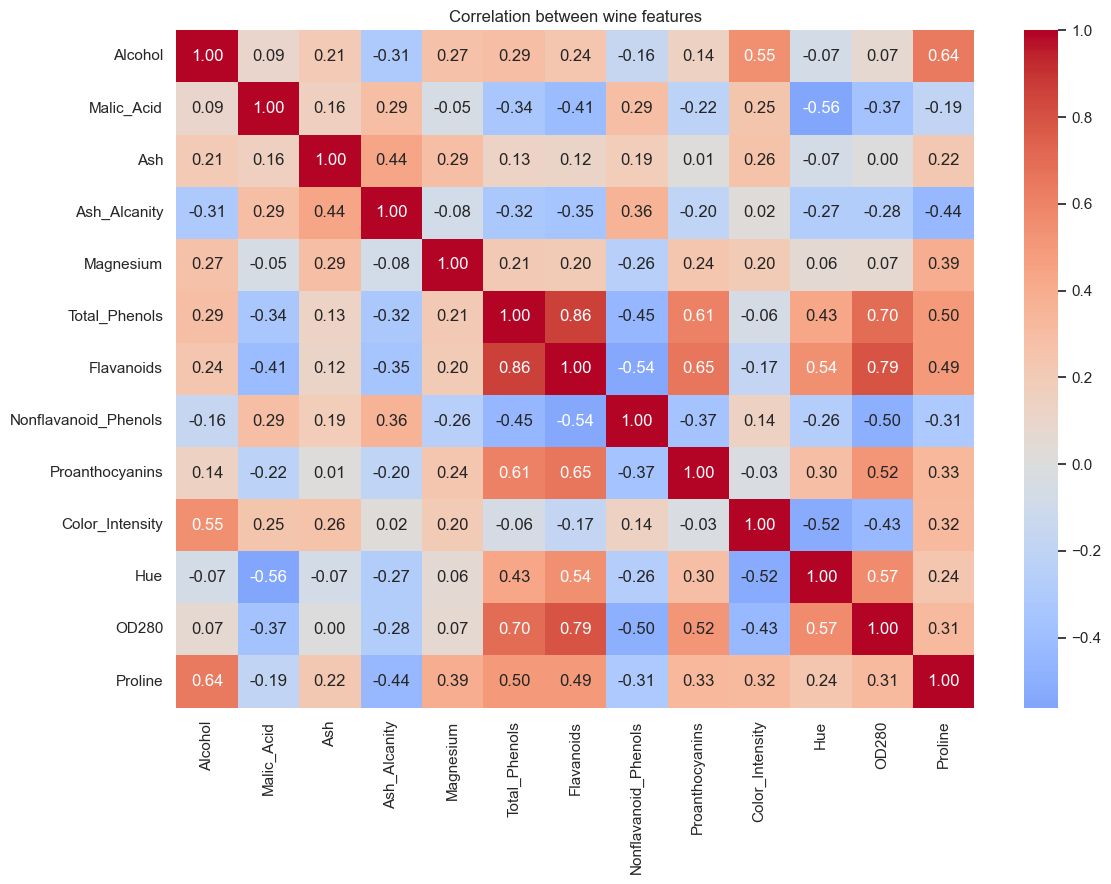

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
# Exclude the categorical target from feature correlations and distributions.
features = data.drop(columns="Customer_Segment").select_dtypes(include="number")

plt.figure(figsize=(12, 9))
sns.heatmap(features.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between wine features")
plt.tight_layout()
plt.show()


### Univariate analysis using KDE

Examine each numeric feature separately using a histogram with a kernel density estimate (KDE) to reveal its distribution shape and spread.

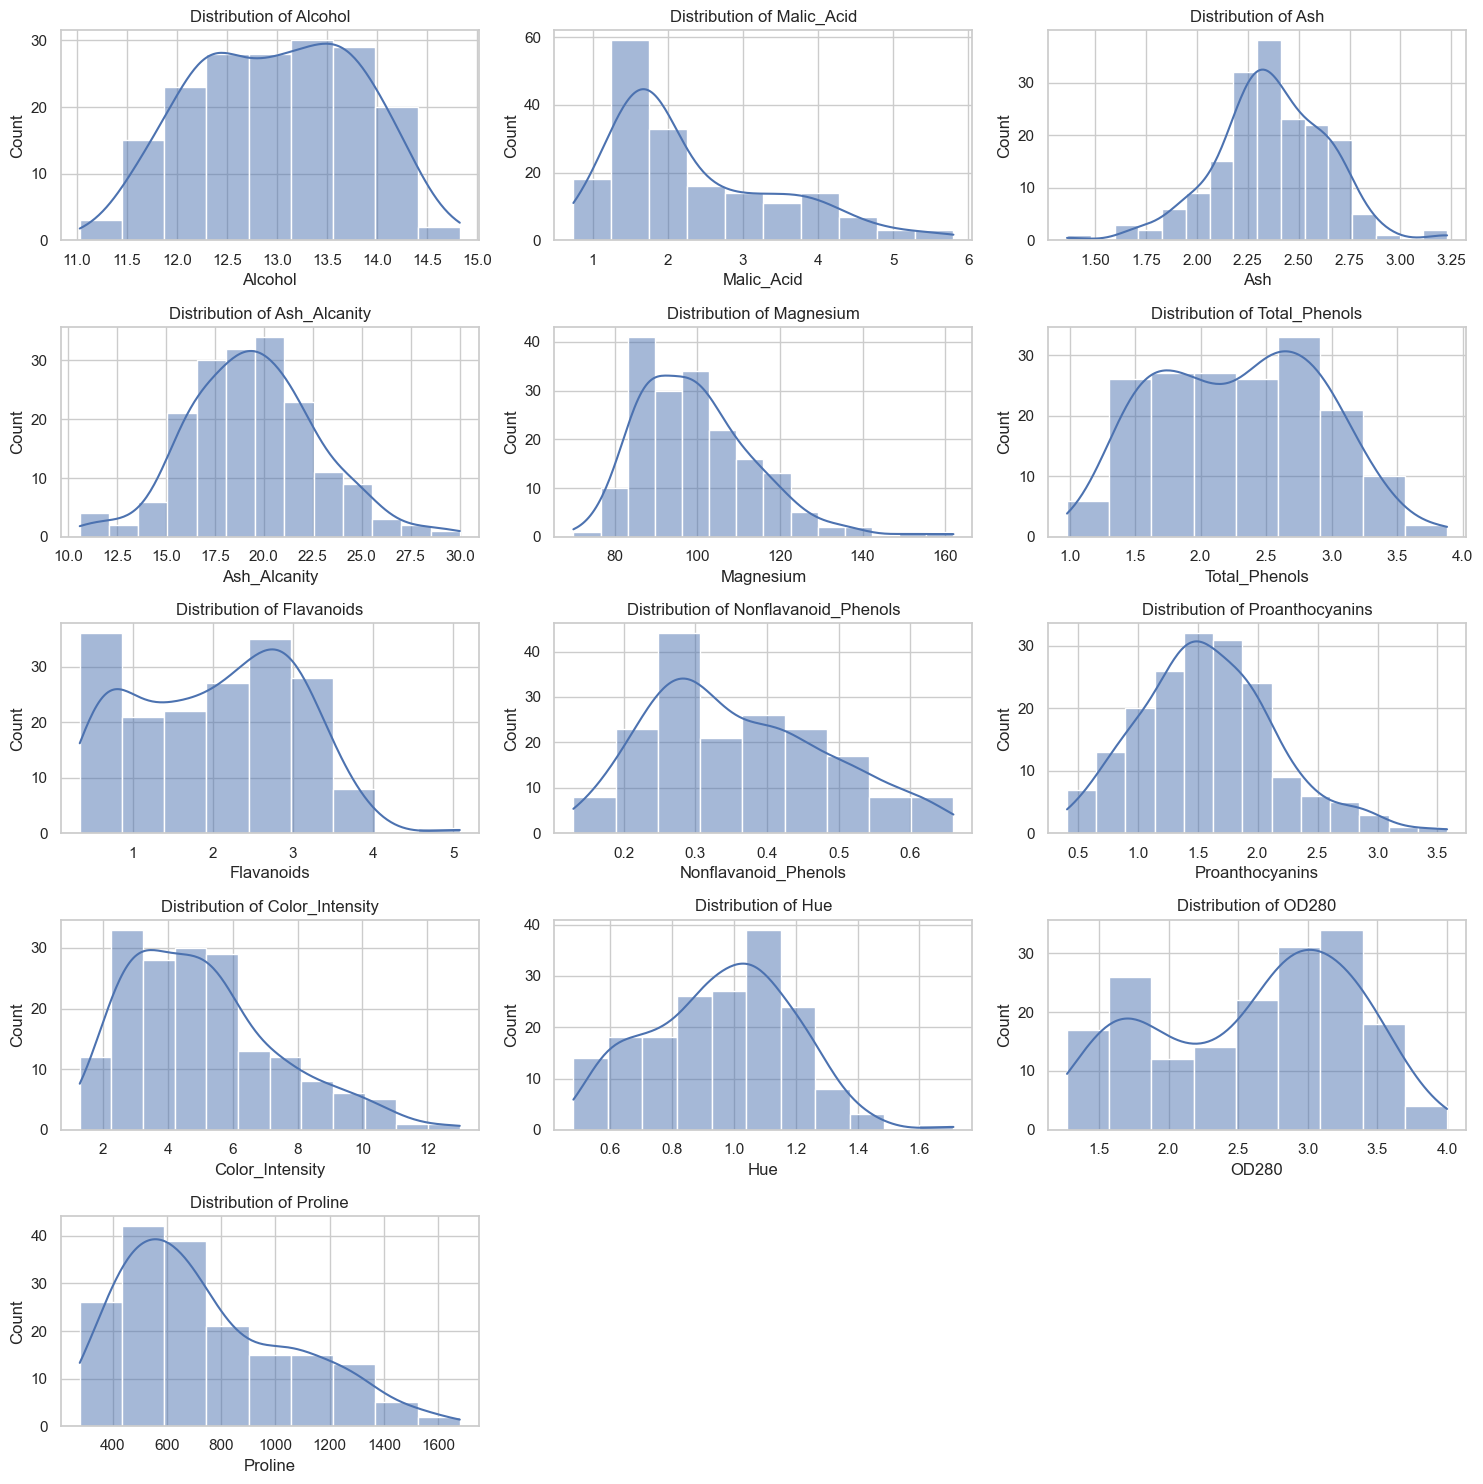

In [8]:
# Univariate analysis: inspect each feature separately.
# kde=True adds a smooth kernel density estimate to each histogram.
ncols = 3
nrows = (len(features.columns) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows))

for ax, column in zip(axes.flat, features.columns):
    sns.histplot(data=data, x=column, kde=True, ax=ax)
    ax.set_title(f"Distribution of {column}")

for ax in list(axes.flat)[len(features.columns):]:
    ax.set_visible(False)

fig.tight_layout()
plt.show()


In [12]:
data.head(2)

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1


In [13]:
data.columns

Index(['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
       'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline',
       'Customer_Segment'],
      dtype='object')

In [15]:
features = ['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
       'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline']
target = ['Customer_Segment']

In [16]:
# Identify X and y
## Method 1
X = data[features]
y = data[target]

X = data.drop("Customer_Segment", axis=1)
y = data["Customer_Segment"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (178, 13)
y shape: (178,)


In [17]:
# Split the data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=123
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 124
Testing records: 54


In [18]:
# Build Logistic Regression model

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
#model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

/opt/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [22]:
model

LogisticRegression()

In [23]:
# Predict

y_pred = model.predict(X_test)

y_pred

array([3, 2, 3, 2, 2, 3, 1, 3, 3, 2, 3, 3, 3, 1, 1, 3, 2, 2, 1, 2, 3, 3,
       3, 3, 2, 3, 3, 2, 1, 1, 1, 1, 3, 2, 3, 2, 2, 1, 2, 2, 3, 3, 1, 1,
       2, 1, 1, 2, 2, 2, 2, 3, 3, 2])

In [25]:
X_test.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
138,13.49,3.59,2.19,19.5,88,1.62,0.48,0.58,0.88,5.70,0.81,1.82,580
60,12.33,1.10,2.28,16.0,101,2.05,1.09,0.63,0.41,3.27,1.25,1.67,680
137,12.53,5.51,2.64,25.0,96,1.79,0.60,0.63,1.10,5.00,0.82,1.69,515
77,11.84,2.89,2.23,18.0,112,1.72,1.32,0.43,0.95,2.65,0.96,2.52,500
90,12.08,1.83,2.32,18.5,81,1.60,1.50,0.52,1.64,2.40,1.08,2.27,480


In [26]:
ndf = X_test.copy()

In [27]:
ndf.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
138,13.49,3.59,2.19,19.5,88,1.62,0.48,0.58,0.88,5.70,0.81,1.82,580
60,12.33,1.10,2.28,16.0,101,2.05,1.09,0.63,0.41,3.27,1.25,1.67,680
137,12.53,5.51,2.64,25.0,96,1.79,0.60,0.63,1.10,5.00,0.82,1.69,515
77,11.84,2.89,2.23,18.0,112,1.72,1.32,0.43,0.95,2.65,0.96,2.52,500
90,12.08,1.83,2.32,18.5,81,1.60,1.50,0.52,1.64,2.40,1.08,2.27,480


In [28]:
ndf.shape

(54, 13)

In [29]:
ndf["actual"] = y_test

In [30]:
ndf.shape

(54, 14)

In [31]:
ndf.head(2)

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,actual
138,13.49,3.59,2.19,19.5,88,1.62,0.48,0.58,0.88,5.70,0.81,1.82,580,3
60,12.33,1.10,2.28,16.0,101,2.05,1.09,0.63,0.41,3.27,1.25,1.67,680,2


In [32]:
ndf["predicted"] = y_pred
ndf.head(5)

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,actual,predicted
138,13.49,3.59,2.19,19.5,88,1.62,0.48,0.58,0.88,5.70,0.81,1.82,580,3,3
60,12.33,1.10,2.28,16.0,101,2.05,1.09,0.63,0.41,3.27,1.25,1.67,680,2,2
137,12.53,5.51,2.64,25.0,96,1.79,0.60,0.63,1.10,5.00,0.82,1.69,515,3,3
77,11.84,2.89,2.23,18.0,112,1.72,1.32,0.43,0.95,2.65,0.96,2.52,500,2,2
90,12.08,1.83,2.32,18.5,81,1.60,1.50,0.52,1.64,2.40,1.08,2.27,480,2,2


In [33]:
ndf[ndf["actual"] != ndf["predicted"]]

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,actual,predicted
142,13.52,3.17,2.72,23.5,97,1.55,0.52,0.50,0.55,4.35,0.89,2.06,520,3,2
24,13.50,1.81,2.61,20.0,96,2.53,2.61,0.28,1.66,3.52,1.12,3.82,845,1,2


In [34]:
# Evaluate the model

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9629629629629629

Confusion Matrix:
[[13  1  0]
 [ 0 18  0]
 [ 0  1 21]]

Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.93      0.96        14
           2       0.90      1.00      0.95        18
           3       1.00      0.95      0.98        22

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54

